<a href="https://colab.research.google.com/github/Ayoraham/receipt_scanner_V2/blob/main/docunment_classification_layoumv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip install --progress-bar off \
    selenium \
    Selenium-Screenshot \
    pytesseract \
    Pillow==9.0.1 \
    transformers \
    pytorch-lightning

  Preparing metadata (setup.py) ... done
  Created wheel for Pillow: filename=Pillow-9.0.1-cp312-cp312-linux_x86_64.whl size=1185285 sha256=48edc6cce7e083b462458bc519500cfb342bed4cd6e08426f540f1fc12f2345b
  Stored in directory: /root/.cache/pip/wheels/ee/0a/b9/549cee15e420c0ccd7b6ab0f5d82e318a66a157379f4d5fdce
Successfully built Pillow
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.0.1 which is incompatible.
torchtune 0.6.1 requires Pillow>=9.4.0, but you have pillow 9.0.1 which is incompati

In [ ]:
!apt-get update -qq > /dev/null

!apt-get install -y chromium-chromedriver -qq > /dev/null

!apt-get install -y tesseract-ocr -qq > /dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("drcrabkg/financial-statements-clustering")

print("Path to dataset files:", path)

100%|██████████| 2.96M/2.96M [00:00<00:00, 119MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/drcrabkg/financial-statements-clustering/versions/1


In [ ]:
from pathlib import Path
path = Path(path)
list(path.iterdir())

[PosixPath('/root/.cache/kagglehub/datasets/drcrabkg/financial-statements-clustering/versions/1/TableClassifierQuaterlyWithNotes')]

In [ ]:
data_pth = Path(path/'TableClassifierQuaterlyWithNotes')

In [ ]:
!ls $data_pth

'Balance Sheets'  'Cash Flow'  'Income Statement'   Notes   Others


In [ ]:

! pip install transformers[vision] pytesseract

import transformers
print(transformers.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 39.3 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: Pillow 9.0.1
    Uninstalling Pillow-9.0.1:
      Successfully uninstalled Pillow-9.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.0 which is incompatible.
5.0.0


In [ ]:
! pip  install playwright

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 13.8 MB/s eta 0:00:00


In [ ]:
from transformers import LayoutLMv3Processor, LayoutLMv3ForSequenceClassification
import PIL
from selenium import webdriver

from tqdm.auto import tqdm
from PIL import Image, ImageDraw
import numpy as np
import sys
from pathlib import Path
print(f"Pillow version: {PIL.__version__}")

Pillow version: 12.1.0


In [ ]:
import shutil
input_path = Path('/root/.cache/kagglehub/datasets/drcrabkg/financial-statements-clustering/versions/1')
working_path = Path('/kaggle/working/processed_data')

if not working_path.exists():
    shutil.copytree(input_path, working_path)
data_path = Path("/kaggle/working/processed_data/TableClassifierQuaterlyWithNotes")

In [ ]:
list(data_path.iterdir())

[PosixPath('/kaggle/working/processed_data/TableClassifierQuaterlyWithNotes/Notes'),
 PosixPath('/kaggle/working/processed_data/TableClassifierQuaterlyWithNotes/Others'),
 PosixPath('/kaggle/working/processed_data/TableClassifierQuaterlyWithNotes/Income Statement'),
 PosixPath('/kaggle/working/processed_data/TableClassifierQuaterlyWithNotes/Cash Flow'),
 PosixPath('/kaggle/working/processed_data/TableClassifierQuaterlyWithNotes/Balance Sheets')]

In [ ]:
data_pth

PosixPath('/kaggle/input/financial-statements-clustering/TableClassifierQuaterlyWithNotes')

In [ ]:
for pth in data_path.iterdir():
  new_name = pth.name.lower().replace(" ","_")
  pth.rename(pth.parent/new_name)

In [ ]:
image_data = Path("screenshot_data")
categories = [cat.name for cat in data_pth.iterdir()]
for cat in categories:

  np = image_data/cat
  np.mkdir(parents=True,exist_ok=True)

In [ ]:
# 1. Install Playwright and its specific browser binaries
!pip install playwright -qqq
!playwright install chromium
!playwright install

# 2. Capture your HTML
import os
import asyncio
from playwright.async_api import async_playwright

async def capture_screenshot(html_path, output_name):
    async with async_playwright() as p:
        # Launching with no-sandbox (required for Colab)
        browser = await p.chromium.launch(args=["--no-sandbox"])
        page = await browser.new_page()

        # Set a 1000x1000 viewport for easy LayoutLMv3 coordinate mapping
        await page.set_viewport_size({"width": 1000, "height": 1000})

        await page.goto(f"file://{os.path.abspath(html_path)}")
        await page.screenshot(path=output_name)
        await browser.close()
        print(f"Success! {output_name} saved.")

# Run it (Colab supports top-level await or asyncio.run)
#await capture_screenshot("your_file.html", "layoutlm_input.png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
test = str(data_path/"cash_flow/18460658_57.html")
!playwright install-deps
await capture_screenshot(test, "layoutlm_input.png")

Installing dependencies...
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-freefont-ttf is already the newest version (20120503-10build1

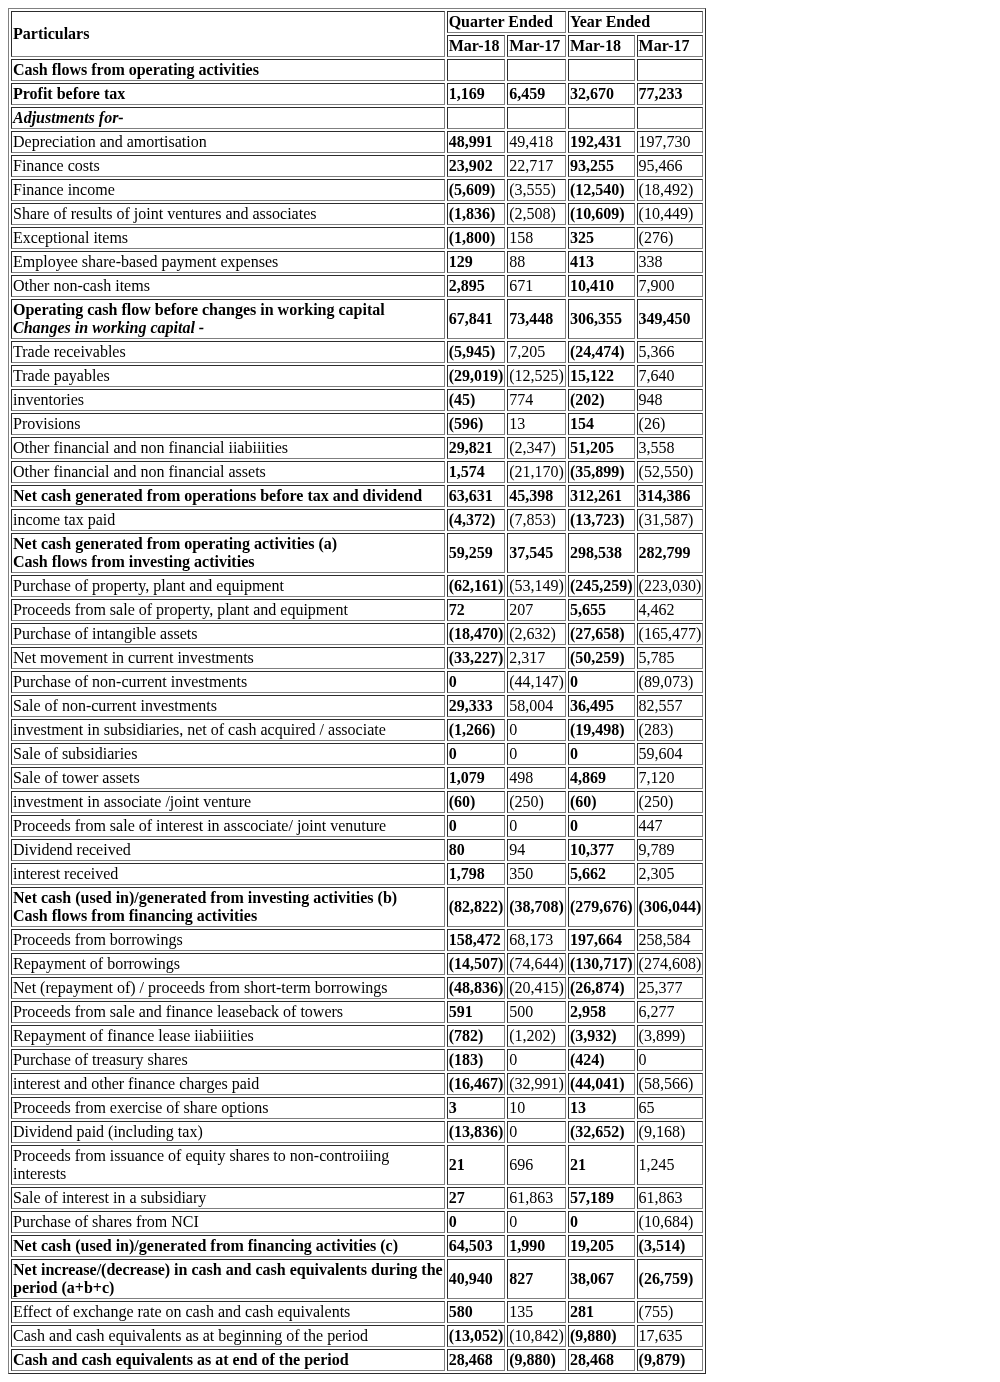

In [ ]:
from IPython.display import Image
Image(filename='layoutlm_input.png')

In [ ]:
!ls $data_pth

'Balance Sheets'  'Cash Flow'  'Income Statement'   Notes   Others


In [ ]:
import shutil
docs = Path("docs")
copy_dir = str(data_pth)
shutil.copytree(copy_dir,docs,dirs_exist_ok=True)


PosixPath('docs')

In [ ]:
docs_pth = Path("docs")
for pth in docs_pth.iterdir():
    new_name = pth.name.lower().replace(" ","_")
    pth.rename(pth.parent/new_name)

In [ ]:
scr_pth = Path("screenshot_data")
for pth in scr_pth.iterdir():
    new_name = pth.name.lower().replace(" ","_")
    pth.rename(pth.parent/new_name)

In [ ]:
from tqdm.auto import tqdm
for cat,scr_cat in tqdm(zip(docs_pth.iterdir(),scr_pth.iterdir())):
  for file in cat.iterdir():
    output_pth = scr_cat/file.with_suffix(".png").name
    await capture_screenshot(str(file),str(output_pth))


0it [00:00, ?it/s]

Success! screenshot_data/balance_sheets/18582935_3.png saved.
Success! screenshot_data/balance_sheets/18475343_2.png saved.
Success! screenshot_data/balance_sheets/18849925_2.png saved.
Success! screenshot_data/balance_sheets/18475343_10.png saved.
Success! screenshot_data/balance_sheets/18889450_5.png saved.
Success! screenshot_data/balance_sheets/18679715_2.png saved.
Success! screenshot_data/balance_sheets/18944710_8.png saved.
Success! screenshot_data/balance_sheets/18825389_7.png saved.
Success! screenshot_data/balance_sheets/18853005_12.png saved.
Success! screenshot_data/balance_sheets/18856919_2.png saved.
Success! screenshot_data/balance_sheets/18759708_4.png saved.
Success! screenshot_data/balance_sheets/18889483_3.png saved.
Success! screenshot_data/balance_sheets/18964857_12.png saved.
Success! screenshot_data/balance_sheets/18756043_4.png saved.
Success! screenshot_data/balance_sheets/18582961_9.png saved.
Success! screenshot_data/balance_sheets/18776679_4.png saved.
Succe

In [ ]:
ex  = scr_pth/"balance_sheets/18391125_2.png"
import cv2 as cv
img=cv.imread(str(ex))
img.size

4284000

In [ ]:
img.shape

(1428, 1000, 3)

In [ ]:
processor = LayoutLMv3Processor.from_pretrained("microsoft/layoutlmv3-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

In [ ]:
encoding = processor(
    image,
    text=words,

)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Zip the folder
!zip -r processed_data.zip /content/screenshot_data

# 2. Move the zip file to Drive
!cp processed_data.zip /content/drive/MyDrive/

  adding: content/screenshot_data/ (stored 0%)
  adding: content/screenshot_data/balance_sheets/ (stored 0%)
  adding: content/screenshot_data/balance_sheets/18666982_5.png (deflated 11%)
  adding: content/screenshot_data/balance_sheets/18667554_3.png (deflated 11%)
  adding: content/screenshot_data/balance_sheets/18723339_10.png (deflated 9%)
  adding: content/screenshot_data/balance_sheets/18679715_2.png (deflated 10%)
  adding: content/screenshot_data/balance_sheets/18492995_5.png (deflated 11%)
  adding: content/screenshot_data/balance_sheets/18889570_7.png (deflated 7%)
  adding: content/screenshot_data/balance_sheets/18506937_3.png (deflated 20%)
  adding: content/screenshot_data/balance_sheets/18676827_12.png (deflated 10%)
  adding: content/screenshot_data/balance_sheets/18889406_3.png (deflated 11%)
  adding: content/screenshot_data/balance_sheets/18914978_10.png (deflated 9%)
  adding: content/screenshot_data/balance_sheets/18853011_3.png (deflated 9%)
  adding: content/scree

In [ ]:
#! pip install pytesseract
import pytesseract
from pytesseract import Output
from PIL import Image

def get_words_boxes(image_pth):
  img = Image.open(image_pth).convert("RGB")
  width,height = img.size
  data = pytesseract.image_to_data(img, output_type=Output.DICT, config='--psm 6')
  words = []
  boxes = []

  for i in range(len(data['text'])):
    if data['text'][i].strip():
        words.append(data['text'][i])

        x1 = int(1000 * (data['left'][i] / width))
        y1 = int(1000 * (data['top'][i] / height))
        x2 = int(1000 * ((data['left'][i] + data['width'][i]) / width))
        y2 = int(1000 * ((data['top'][i] + data['height'][i]) / height))

        boxes.append([x1, y1, x2, y2])
  return words, boxes


In [ ]:
from pathlib import Path
import shutil
zipped_data_pth = "drive/MyDrive/processed_data.zip"
data_pth = "data"

shutil.unpack_archive(zipped_data_pth,data_pth)

In [ ]:
content = Path("data/content/screenshot_data")
test = content/"balance_sheets/18391125_2.png"
import cv2 as cv
img = cv.imread(str(test))
img.shape

(1000, 1000, 3)

In [ ]:
import json
from pathlib import Path

dataset = []
class_names = ["balance_sheet", "income_statement", "cash_flow", "notes","others"]

for class_idx, class_name in enumerate(class_names):
    class_folder = Path(f"data/content/screenshot_data/{class_name}")

    for img_path in class_folder.glob("*.png"):
        # 1. Run your OCR function
        words, boxes = get_words_boxes(img_path)

        # 2. Store the data
        dataset.append({
            "image_path": str(img_path),
            "label": class_idx,
            "words": words,
            "boxes": boxes
        })

# 3. Save everything to one file in your Drive
with open("/content/drive/MyDrive/layoutlm_dataset.json", "w") as f:
    json.dump(dataset, f)

In [ ]:
from google.colab import drive
drive.mount

<function google.colab.drive.mount(mountpoint, force_remount=False, timeout_ms=120000, readonly=False)>

In [ ]:
import json
data_pth = "/content/drive/MyDrive/layoutlm_dataset.json"
with open(data_pth, "r") as f:
  data = json.load(f)

In [ ]:
len(data)

2291

In [ ]:
data[0].keys()

dict_keys(['image_path', 'label', 'words', 'boxes'])

In [ ]:
import zipfile
from pathlib import Path
src_img_pth = "/content/drive/MyDrive/processed_data.zip"
dest_pth = "data/content"
#Path.mkdir(dest_pth, exist_ok=True)
with zipfile.ZipFile(src_img_pth,'r') as impth:
  impth.extractall(dest_pth)

print(f"All files extracted to {dest_pth}")


All files extracted to data/content


In [ ]:
import shutil
src_pth = "data/content/content/screenshot_data"
dest_pth = "data/content/screenshot_data"
shutil.copytree(src_pth,dest_pth)

'data/content/screenshot_data'

In [ ]:
shutil.rmtree("data/content/content")

In [ ]:
from transformers import LayoutLMv3Processor

In [ ]:
processor = LayoutLMv3Processor.from_pretrained("microsoft/layoutlmv3-base")
processor.image_processor.apply_ocr = False

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
from PIL import Image
class SROIEDATASET(Dataset):
  def __init__(self,data_list,processor,max_length=512):
    """
    Args:
      data_list: List of dicts with keys ['image_path,label,words,bboxes]
      processor: The pretrained layoutlmv3 model
      max_length: max no of tokens the model can process in a single pass
    """
    self.data_list = data_list
    self.processor = processor
    self.max_length = max_length


  def __len__(self):
    return(len(self.data_list))

  def __getitem__(self,idx):
    item = self.data_list[idx]

    # Load image
    image = Image.open(item['image_path']).convert('RGB')

    encoding = self.processor(
    image,
    text=item['words'],
    boxes=item['boxes'],
    truncation=True,
    padding='max_length',
    max_length=self.max_length,
    return_tensors='pt',

                          )

    item_encoding = {k: v.squeeze(0) for k,v in encoding.items()}
    item_encoding['labels'] = torch.tensor(item['label'], dtype=torch.long)

    return item_encoding



In [ ]:
import torch
torch.cuda.is_available()


True

In [ ]:
from torch.utils.data import DataLoader

train_dataset = SROIEDATASET(data,processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

first_batch = next(iter(train_loader))
print(first_batch.keys())

dict_keys(['input_ids', 'attention_mask', 'bbox', 'pixel_values', 'labels'])


In [ ]:
first_batch['pixel_values'].shape

torch.Size([2, 3, 224, 224])

In [ ]:
from transformers import LayoutLMv3ForSequenceClassification

model = LayoutLMv3ForSequenceClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=5
)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForSequenceClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight            | MISSING    | 
classifier.dense.bias              | MISSING    | 
classifier.out_proj.weight         | MISSING    | 
classifier.out_proj.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from torch.optim import AdamW
from tqdm import tqdm

# 1. Setup Optimizer (Lower learning rate is better for Transformers)
optimizer = AdamW(model.parameters(), lr=5e-5)

model.train()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Training starting on {device}...")

for epoch in range(20):  # Start with 3 epochs
    total_loss = 0
    for batch in tqdm(train_loader):
        # Move everything in the batch to GPU/CPU
        inputs = {k: v.to(device) for k, v in batch.items()}

        # Forward pass
        outputs = model(**inputs)

        # Get the loss (LayoutLMv3 calculates this automatically if 'labels' is in the batch)
        loss = outputs.loss

        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} complete. Average Loss: {avg_loss:.4f}")

Training starting on cuda...


100%|██████████| 1146/1146 [09:28<00:00,  2.02it/s]


Epoch 1 complete. Average Loss: 1.0557


100%|██████████| 1146/1146 [09:33<00:00,  2.00it/s]


Epoch 2 complete. Average Loss: 1.0441


...

100%|██████████| 1146/1146 [09:32<00:00,  2.00it/s]


Epoch 5 complete. Average Loss: 1.0456


100%|██████████| 1146/1146 [09:31<00:00,  2.00it/s]


Epoch 6 complete. Average Loss: 1.0485


 21%|██        | 243/1146 [02:01<07:19,  2.05it/s]

#LAST  TEST

In [ ]:
from google.colab import drive
drive.mount

<function google.colab.drive.mount(mountpoint, force_remount=False, timeout_ms=120000, readonly=False)>

In [ ]:
import zipfile
from pathlib import Path
src_img_pth = "/content/drive/MyDrive/processed_data.zip"
dest_pth = "data/content"
#Path.mkdir(dest_pth, exist_ok=True)
with zipfile.ZipFile(src_img_pth,'r') as impth:
  impth.extractall(dest_pth)

print(f"All files extracted to {dest_pth}")


All files extracted to data/content


In [ ]:
import shutil
src_pth = "data/content/content/screenshot_data"
dest_pth = "data/content/screenshot_data"
shutil.copytree(src_pth,dest_pth)

'data/content/screenshot_data'

In [ ]:
shutil.rmtree("data/content/content")


In [ ]:
from transformers import LayoutLMv3Processor

In [ ]:
processor = LayoutLMv3Processor.from_pretrained("microsoft/layoutlmv3-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

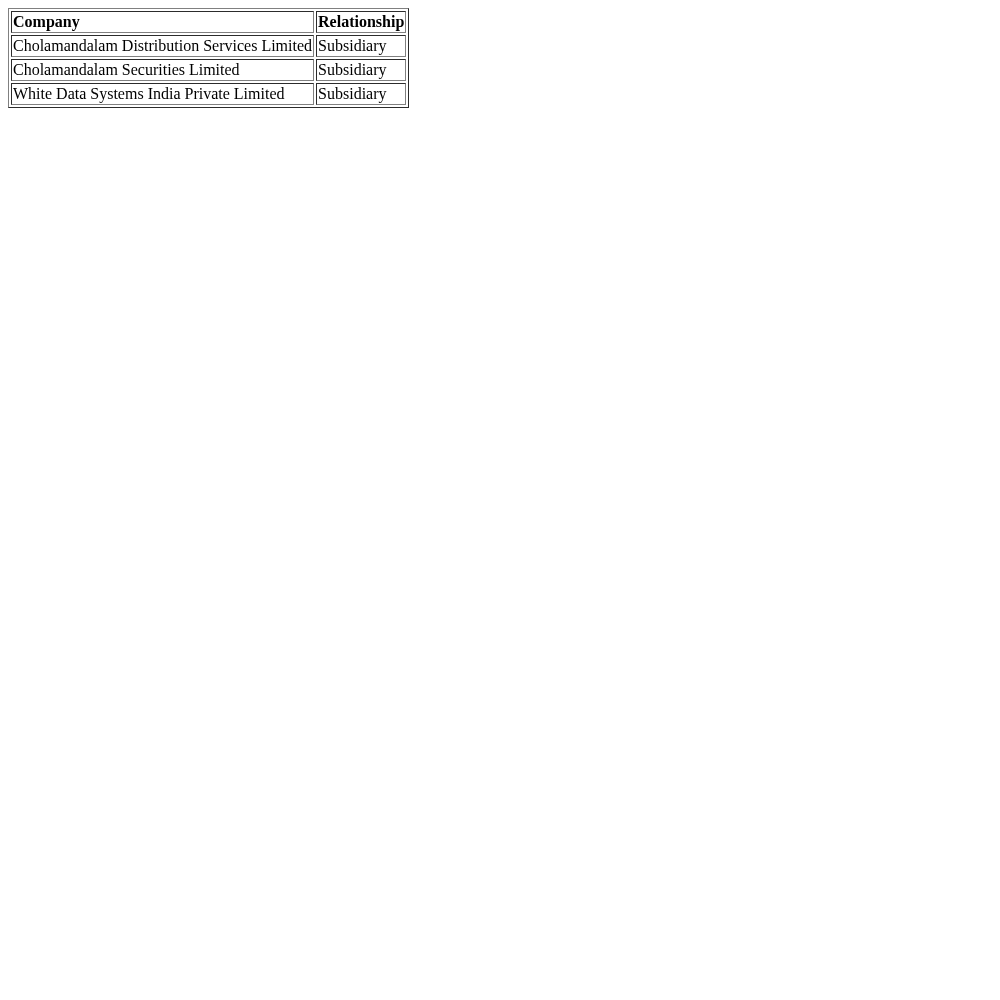

In [ ]:
from PIL import Image
from pathlib import Path
import random

folder_path = Path("data/content/screenshot_data")
image_list = []
for cat in folder_path.iterdir():
  for img in cat.iterdir():
    image_list.append(img)
image_pth = random.choice(image_list)

image = Image.open(image_pth).convert("RGB")
image

In [ ]:
!pip install pytesseract

In [ ]:
encoding = processor(
    image,
    max_length =  512,
    padding = "max_length",
    truncation = True,
    return_tensors = "pt",
)


In [ ]:
encoding.keys()

KeysView({'input_ids': tensor([[    0,   646,  4741, 21953,    29,   646, 15299,   104,  3384,  1721,
         10975,  2688,  5161, 29504,   646,  1620,    23,   646,  1620,    23,
         12655,    36,  2983,    12,  3933,    12,  2464, 10975,  2983,    12,
          3933,    12,  3789,    43,   226,   646, 37779,  4560,   646, 37779,
          4560,   646, 17042, 18827,  1721, 33239,    12, 28311,  1781, 18363,
            43, 10491,     6,  2195,     8,  2104,   646,   134,     6, 38071,
             4,  3103,   646,   134,     6, 31920,     4,  3367,   646,  1721,
           428,    43,  1867,   173,    12,   179,    12, 38265, 13383,  1646,
             4,   612,    36, 22388,     4,  4540,   646,  1215,   863,  4082,
          2830,  1038,   195,     4,  1360,   646,   306,     4,  5449,   646,
          1215, 15483,  1039,  2497,  6677,    36,   246,     6,   245,  2881,
             4,  4015,   646,   246,     6, 31546,     4,  1558,   646, 46386,
           242,    43,  1944,

In [ ]:
from transformers import LayoutLMv3ForSequenceClassification

model = LayoutLMv3ForSequenceClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForSequenceClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.bias              | MISSING    | 
classifier.dense.weight            | MISSING    | 
classifier.out_proj.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model.config

LayoutLMv3Config {
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "coordinate_size": 128,
  "dtype": "float32",
  "eos_token_id": 2,
  "has_relative_attention_bias": true,
  "has_spatial_attention_bias": true,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "input_size": 224,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-05,
  "max_2d_position_embeddings": 1024,
  "max_position_embeddings": 514,
  "max_rel_2d_pos": 256,
  "max_rel_pos": 128,
  "model_type": "layoutlmv3",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "patch_size": 16,
  "rel_2d_pos_bins": 64,
  "rel_pos_bins": 32,
  "second_input_size": 112,
  "shape_size": 128,
  "text_embed": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "visual_embed": true,
  "vocab_size": 50265
}

In [ ]:
!pip -qqq install easyocr
import easyocr
reader = easyocr.Reader